The Titanic sank in 1912 after hitting an iceber, killing around 1500 people out of the 2200 population. The dataset used has information on 891 passengers regarding their age, sex, ticket class, and whether they made it out alive. This notebook takes a closer look into the realtionship between the odds of surviving with respect to class, age and a combination of class & sex.

In [14]:
# data visualization library and has built in data-sets
import seaborn as sns

# pandas works with tabular data like spreadsheets
import pandas as pd

#makes charts and graphs
import matplotlib.pyplot as plt

#handles humerical operations and arrays
import numpy as np


In [15]:
#load dataset from seaborn, gives pandas DataFrame
df = sns.load_dataset("titanic")

#first 5 rows to understand the structure
print("First 5 rows")
print(df.head())

#how many rows and columns exist
print("\nShape:", df.shape)

#column names, data types and missing values
print("\nColumn Info:")
df.info()


First 5 rows
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Shape: (891, 15)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------

In [16]:
#overall % of survived population by finding the mean of people who survived:
print(f"Survived %: {df["survived"].mean() * 100:.1f}")

Survived %: 38.4


In [17]:
#Survival by class, by multiplying class with mean:
print(f"Survival by class: {df.groupby("pclass")["survived"].mean()*100}")

Survival by class: pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64


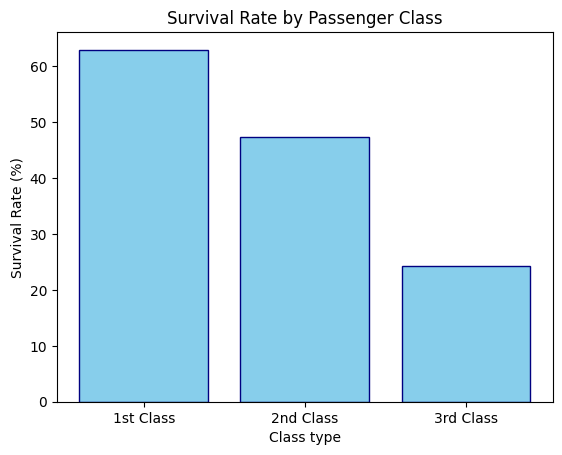

In [18]:
#put surivival by class in a variable
survived_class = df.groupby("pclass")["survived"].mean()*100

#x-axis
class_type = ["1st Class", "2nd Class", "3rd Class"]

#bar chart
plt.bar(class_type, survived_class, color = "skyblue", edgecolor = "navy")

#label x & y axis
plt.xlabel("Class type")
plt.ylabel("Survival Rate (%)")
plt.title("Survival Rate by Passenger Class")

# saving as png to use later in the readme
plt.savefig('survived_class.png')
plt.show()

Passengers in first class had the highest survival chance(62.9%), while lowest class had the opposite(24.2%).A possible reason is due to the placements of the cabins on the ship, wealthier population were closest to the evacuation route.

In [19]:
#Ages of passengers who survived
#Goes through every row and checks if passenger survived or not
survivors = df["survived"] == 1

#Gives only the ones who survived, row | age
survived_ages = df[survivors]["age"]
print(survived_ages)

1      38.0
2      26.0
3      35.0
8      27.0
9      14.0
       ... 
875    15.0
879    56.0
880    25.0
887    19.0
889    26.0
Name: age, Length: 342, dtype: float64


In [20]:
#Ages of passengers who didn't survive
non_survivors = df["survived"] == 0
non_survived_ages = df[non_survivors]["age"]
print(non_survived_ages)

0      22.0
4      35.0
5       NaN
6      54.0
7       2.0
       ... 
884    25.0
885    39.0
886    27.0
888     NaN
890    32.0
Name: age, Length: 549, dtype: float64


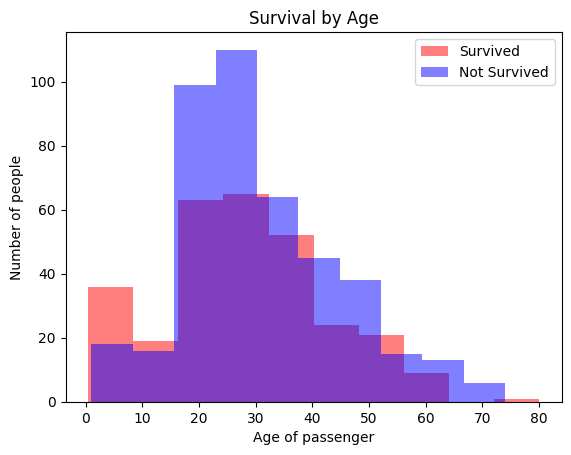

In [21]:
#histogram plot for survival by age
plt.hist(survived_ages, alpha = 0.5, label = "Survived", color = "Red")
plt.hist(non_survived_ages, alpha = 0.5, label = "Not Survived", color = "Blue")
plt.legend(loc = "upper right")
plt.title("Survival by Age")
plt.xlabel("Age of passenger")
plt.ylabel("Number of people")

# saving as png to use later in the readme
plt.savefig('age_distribution.png')
plt.show()

Chart demonstrates children under 10 had the highest survival rate compared to other age groups.  This likely reflects the evacuation priority given to children during the disaster. The 20 -40 age range had the lowest survival rate, and the older population had more death rates in comparison to survival, even though fewer in number. Children clearly were given priority.

In [22]:
#Survival by class and gender(sex)
print(f"Survived_Class&Gender = {df.groupby(["pclass","sex"])["survived"].mean()*100}")

Survived_Class&Gender = pclass  sex   
1       female    96.808511
        male      36.885246
2       female    92.105263
        male      15.740741
3       female    50.000000
        male      13.544669
Name: survived, dtype: float64


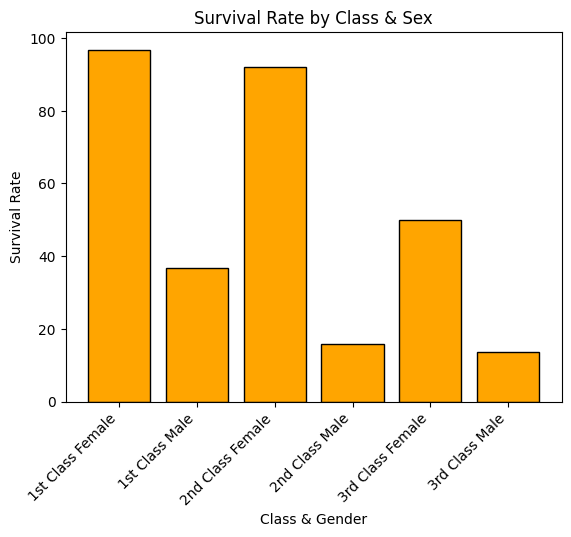

In [23]:
#bar plot of survival by class and gender(sex)
survival_class_gender = df.groupby(["pclass","sex"])["survived"].mean()*100

categories = ["1st Class Female", "1st Class Male", "2nd Class Female", "2nd Class Male", "3rd Class Female", "3rd Class Male"]

plt.bar(categories, survival_class_gender, color='orange', edgecolor='black')
plt.title("Survival Rate by Class & Sex")
plt.xlabel("Class & Gender")
plt.ylabel("Survival Rate")


plt.savefig("Survival_Class_gener.png")
plt.xticks(rotation=45, ha='right')
plt.show()

The diagram clearly indicates that women were given priority over men when it came to evacuation, regardless of the class. 1st class men had lower chances of making it out alive in comparison to 3rd class female, clearly class was not the factor, rather gender. The highest survival rate went to the female population from 1st Class.

Ticket Class, Age and Sex were the key factors that came into play when deciding the fate of the passengers. Gender was the prominent key amongst them, with class coming in at second. Age played a smaller role mainly in the fact that children were given priority. These factors highlight the system of the evacuation scheme and social hierarchy.  